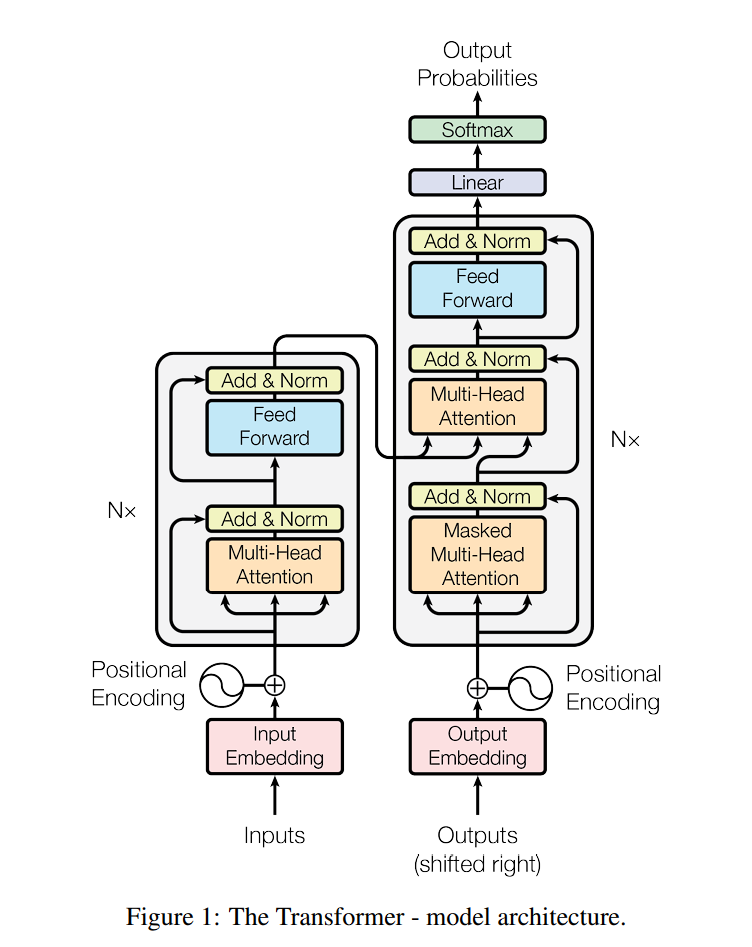

In [1]:
import torch.nn as nn
import torch
import math

class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.is_bias = bias
        self.weight = torch.nn.Parameter(torch.rand(self.in_features, self.out_features))

        if self.is_bias:
            self.bias = torch.nn.Parameter(torch.rand(self.out_features))
    
    def forward(self, x: torch.tensor):
        output = x @ self.weight
        if self.is_bias:
            output += self.bias
        return output

class LayerNorm(nn.Module):
    def __init__(self, in_features: int, eps: float = 0.001):
        super().__init__()
        self.in_features = in_features
        self.gamma = torch.nn.Parameter(torch.ones(self.in_features))
        self.beta = torch.nn.Parameter(torch.zeros(self.in_features))
        self.eps = eps
    
    def forward(self, x: torch.tensor):
        x_mean = x.mean(dim = -1, keepdim = True)
        x_var = x.var(dim = -1, keepdim = True, unbiased = False)
        x_norm = (x - x_mean) / torch.sqrt(x_var + self.eps)
        return x_norm * self.gamma + self.beta

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model: int, d_q: int, d_v: int):
        super().__init__()

        self.W_q = torch.nn.Parameter(torch.rand(d_model, d_q))
        self.W_k = torch.nn.Parameter(torch.rand(d_model, d_q))
        self.W_v = torch.nn.Parameter(torch.rand(d_model, d_v))

        self.d_q = d_q
        self.d_v = d_v
    
    def _compute_attention_scores(self, Query: torch.tensor, Key: torch.tensor, Value: torch.tensor):
        d_k = self.d_q
        A = Query @ Key.transpose(-1, -2)
        adj_A = torch.softmax((A / (d_k ** 0.5)), dim = -1)
        Z = adj_A @ Value
        return Z
    
    def forward(self, x: torch.tensor):
        Query = x @ self.W_q
        Key = x @ self.W_k
        Value = x @ self.W_v
        return self._compute_attention_scores(Query, Key, Value)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, h: int):
        super().__init__()
        
        assert d_model % h == 0, "d_model must be Divisible by h"
        self.d_model = d_model
        self.h = h
        self.d_k = self.d_model // self.h
        self.d_v = self.d_k

        self.W_q = torch.nn.Parameter(torch.rand(d_model, h * self.d_k))
        self.W_k = torch.nn.Parameter(torch.rand(d_model, h * self.d_k))
        self.W_v = torch.nn.Parameter(torch.rand(d_model, h * self.d_v))

        # Linear projection for Converting from concatinated d_model to real d_mdoel, mixing the learned features
        self.linear_projection = LinearLayer(in_features = self.d_model, out_features = self.d_model)

    def _compute_attention_scores(self, Query: torch.tensor, Key: torch.tensor, Value: torch.tensor, mask: torch.tensor = None):
        # B, h, T, d_q = Query.shape
        # B, h, T, d_q = Key.shape
        A = Query @ Key.transpose(-1, -2) # A.shape = (B, h, T, d_q) @ (B, h, T, d_q).T = (B, h, T, d_q) @ (B, h, d_q, T) --> (B, h, T, T)
        A = A / (self.d_k ** 0.5)
        if mask is not None:
            A = A.masked_fill(~mask, value = float('-inf'))
        adj_A = torch.softmax(A, dim = -1)
        Z = adj_A @ Value
        return Z
    
    def forward(self, x: torch.tensor, mask: torch.tensor = None):
        B, T, d_model = x.shape
        query = x @ self.W_q # query.shape = (B, T, d_model) @ (d_model, d_model) = (B, T, d_model) --> (B, T, h, d_k) --> (B, h, T, d_k)
        key = x @ self.W_k
        value = x @ self.W_v

        query = query.reshape(B, T, self.h, self.d_k).transpose(1, 2)
        key = key.reshape(B, T, self.h, self.d_k).transpose(1, 2)
        value = value.reshape(B, T, self.h, self.d_v).transpose(1, 2)

        Z = self._compute_attention_scores(query, key, value, mask)
        return self.linear_projection(Z.transpose(1, 2).contiguous().view(B, T, d_model))

class PositionalEmbeddings(nn.Module):
    def __init__(self, max_seq_length: int, d_model: int):
        super().__init__()

        assert d_model % 2 == 0, "d_model must be divisible by 2"

        pe = torch.zeros(max_seq_length, d_model)

        position = torch.arange(0, max_seq_length).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_seq_length, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor):
        B, T, D = x.shape
        return x + self.pe[:, :T]

class InputEmbeddings(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embeddings = torch.nn.Parameter(torch.rand(vocab_size, d_model) * (d_model ** 0.5))
    
    def forward(self, x: torch.tensor):
        # B, T = x.shape
        x_enc = self.embeddings[x]
        return x_enc

class ResidualConnections(nn.Module):
    def __init__(self, in_features: int, dropout: float, eps: float = 0.001):
        super().__init__()

        self.layer_norm = LayerNorm(in_features, eps)
        self.dropout = torch.nn.Dropout(p = dropout)
    
    def forward(self, x: torch.tensor, sublayer):
        # B, T, d_model = x.shape
        return self.layer_norm(x + self.dropout(sublayer(x)))


class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.layer_1 = LinearLayer(d_model, d_ff, bias = False)
        self.layer_2 = LinearLayer(d_ff, d_model, bias = False)
    
    def forward(self, x: torch.tensor):
        return self.layer_2(torch.nn.ReLU()(self.layer_1(x)))

class CausalMasking:
    def __init__(self, T: int):
        self.mask = torch.tril(torch.ones(T, T)).unsqueeze(0).unsqueeze(0)

    def get_mask(self):
        return self.mask.bool()

class Embeddings(nn.Module):
    def __init__(self, d_model: int, vocab_size: int, max_seq_length: int):
        super().__init__()
        self.token_embeddings = InputEmbeddings(vocab_size = vocab_size, d_model = d_model)
        self.positional_embeddings = PositionalEmbeddings(d_model = d_model, max_seq_length = max_seq_length)
    
    def forward(self, x: torch.tensor):
        return self.positional_embeddings(self.token_embeddings(x))

class Decoder(nn.Module):
    def __init__(self, d_model: int, d_ff: int, h: int, dropout: float):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model = d_model, h = h)
        self.residual_connection_1 = ResidualConnections(d_model, dropout)

        self.feed_forward = FeedForward(d_model = d_model, d_ff = d_ff)
        self.residual_connection_2 = ResidualConnections(in_features = d_model, dropout = dropout)
    
    def forward(self, x: torch.tensor, mask: torch.tensor):
        x = self.residual_connection_1(x, lambda x: self.self_attention(x, mask))
        x = self.residual_connection_2(x, self.feed_forward)
        return x

class Transformer(nn.Module):
    def __init__(self, N: int, d_model: int, d_ff: int, h: int, dropout: float, vocab_size: int):
        super().__init__()
        self.layers = nn.ModuleList([Decoder(d_model = d_model, d_ff = d_ff, h = h, dropout = dropout) for _ in range(N)])
        self.linear_transformation_layer = LinearLayer(d_model, vocab_size, bias = True)

    def forward(self, x: torch.tensor, mask: torch.tensor):
        for layer in self.layers:
            x = layer(x, mask)
        return self.linear_transformation_layer(x)

In [2]:
d_model = 512
seq_length = T = 24
batch_size = 8
vocab_size = 27
max_seq_length = 100
dropout = 0.1
d_ff = 2048
N = 10
h = 8

x = torch.randint(0, vocab_size, (batch_size, T))
y = torch.roll(x, shifts=-1, dims=1)
embeddings = Embeddings(d_model = d_model, vocab_size = vocab_size, max_seq_length = max_seq_length)
x_enc = embeddings(x)

In [3]:
mask = CausalMasking(T).get_mask()

In [4]:
transformer = Transformer(
    N = N,
    d_model = d_model,
    d_ff = d_ff,
    h = h,
    dropout = dropout,
    vocab_size = vocab_size
)

In [5]:
probs = torch.softmax(transformer(x_enc, mask = mask), dim = -1)

In [6]:
import torch.nn.functional as F
optimizer = torch.optim.Adam(params = transformer.parameters(), lr = 0.01)

In [7]:
for i in range(100):
    logits = transformer(x_enc, mask=mask)

    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        y.view(-1)
    )

    optimizer.zero_grad()
    loss.backward(retain_graph=True)
    optimizer.step()

    if i % 10 == 0:
        print(f"Loss: {loss.item()}")

Loss: 13.362761497497559
Loss: 11.154601097106934
Loss: 10.766170501708984
Loss: 9.533957481384277
Loss: 7.755205154418945
Loss: 6.767921447753906
Loss: 6.039827346801758
Loss: 5.300029754638672
Loss: 4.6604743003845215
Loss: 4.260667324066162
